In [1]:
# RCNN for Object Detection on Tiny Object Dataset using TensorFlow and VGG backbone
#Dataset : https://www.kaggle.com/datasets/kailaspsudheer/tiny-object-detection/data
# Step 1: Install and Download Dataset
!pip install kagglehub opencv-contrib-python --quiet
import kagglehub

In [2]:
import os
import json
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import Input, Dense, Flatten, TimeDistributed
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kailaspsudheer/tiny-object-detection")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/tiny-object-detection


In [4]:
!ls /kaggle/input/tiny-object-detection

SkyFusion


In [5]:
# # Explore input files
# for dirname, _, filenames in os.walk('/content/kaggle'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))
# # Download Dataset via KaggleHub
# path = kagglehub.dataset_download("kailaspsudheer/tiny-object-detection", force_download=True)
# print("Dataset Path:", path)

In [6]:
# !cp -R /root/.cache/kagglehub/datasets/kailaspsudheer/tiny-object-detection/versions/4/* /content/kaggle/tiny-object-detection/
path = "/kaggle/input/tiny-object-detection/SkyFusion"

In [7]:
# from google.colab import drive
# drive.mount('/content/drive')

In [8]:
# Utility: Compute Intersection over Union (IoU) between two boxes
def compute_iou(boxA, boxB):
    # box = [x1, y1, x2, y2]
    xA = max(boxA[0], boxB[0]); yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2]); yB = min(boxA[3], boxB[3])
    interW = max(0, xB - xA + 1); interH = max(0, yB - yA + 1)
    interArea = interW * interH
    if interArea == 0:
        return 0.0
    boxAArea = (boxA[2]-boxA[0]+1)*(boxA[3]-boxA[1]+1)
    boxBArea = (boxB[2]-boxB[0]+1)*(boxB[3]-boxB[1]+1)
    return interArea / float(boxAArea + boxBArea - interArea)

# Utility: Draw bounding boxes and labels on an image
def draw_boxes(image, boxes, labels=None, color=(0,255,0), thickness=2):
    img = image.copy()
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box
        cv2.rectangle(img, (x1,y1), (x2,y2), color, thickness)
        if labels is not None:
            cv2.putText(img, labels[i], (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX,
                        0.6, color, 1, cv2.LINE_AA)
    return img

In [9]:
# Paths to dataset (adjust as needed for Colab)
base_path = path
train_image_dir = os.path.join(base_path, "train")
train_ann_file  = os.path.join(base_path, "train/_annotations.coco.json")
valid_image_dir = os.path.join(base_path, "valid")
valid_ann_file  = os.path.join(base_path, "valid/_annotations.coco.json")
test_image_dir  = os.path.join(base_path, "test")
test_ann_file   = os.path.join(base_path, "test/_annotations.coco.json")

In [10]:
# Load annotation
with open(train_ann_file) as f:
    ann = json.load(f)
classes = [cat['name'] for cat in ann['categories']]
num_classes = len(classes)
print("Classes:", classes)

Classes: ['Aircraft', 'ship', 'vehicle']


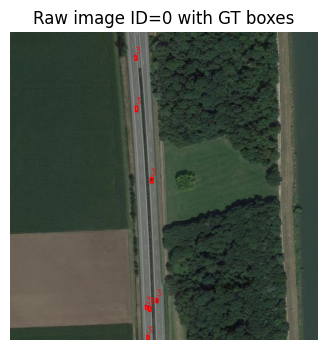

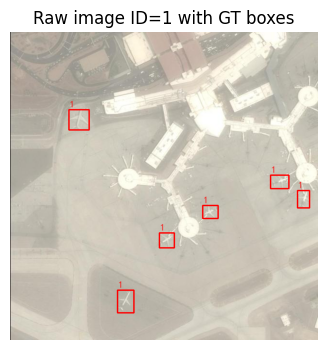

In [11]:
# Load COCO annotations (pseudocode; adjust for actual JSON structure)
with open(train_ann_file) as f:
    ann_data = json.load(f)
# Build mapping from image ID to filename and boxes
images_info = {img['id']: img['file_name'] for img in ann_data['images']}
anns = {}
for a in ann_data['annotations']:
    img_id = a['image_id']
    bbox = a['bbox']  # [x, y, width, height]
    category = a['category_id']
    # Convert bbox to [x1,y1,x2,y2]
    x,y,w,h = bbox
    box = [int(x), int(y), int(x+w), int(y+h)]
    anns.setdefault(img_id, []).append((box, category))

# Example: Display 1-2 sample images with GT boxes
for idx, (img_id, filename) in enumerate(images_info.items()):
    if idx>=2: break
    img_path = os.path.join(train_image_dir, filename)
    # Check if the image file exists
    if not os.path.exists(img_path):
        print(f"Warning: Image file not found at {img_path}. Skipping.")
        continue
    img = cv2.imread(img_path)
    # Check if imread was successful
    if img is None:
        print(f"Warning: Failed to load image from {img_path}. Skipping.")
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Check if there are annotations for this image before accessing anns[img_id]
    if img_id not in anns:
        print(f"Warning: No annotations found for image ID {img_id}. Skipping.")
        continue

    gt_boxes = [b for (b,c) in anns[img_id]]
    gt_labels = [str(c) for (b,c) in anns[img_id]]
    img_annot = draw_boxes(img, gt_boxes, gt_labels, color=(255,0,0))
    plt.figure(figsize=(4,4))
    plt.imshow(img_annot)
    plt.title(f"Raw image ID={img_id} with GT boxes"); plt.axis('off')

In [12]:
# Function to run selective search (Region Proposal Generation) on one image and filter proposals
def get_region_proposals(image, gt_boxes, scale=500, sigma=0.9, min_size=10):
    ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
    ss.setBaseImage(image)
    ss.switchToSelectiveSearchFast()  # faster mode
    rects = ss.process()
    proposals = []
    for (x, y, w, h) in rects:
        # convert to [x1,y1,x2,y2]
        x2, y2 = x+w, y+h
        # filter out very small regions
        if w*h < 500:
            continue
        prop_box = [x, y, x2, y2]
        # compute IoU with all GT boxes
        max_iou = 0
        for gt in gt_boxes:
            iou = compute_iou(prop_box, gt)
            max_iou = max(max_iou, iou)
        # Label positive or negative (we will use for target generation)
        if max_iou > 0.5:
            proposals.append((prop_box, 1))  # positive (foreground)
        elif max_iou < 0.3:
            proposals.append((prop_box, 0))  # negative (background)
        # else: ignore proposals with 0.3<=IoU<=0.5 (ambiguous)
    return proposals

# Example: Run on one sample image
# (In actual code, loop over all images to build ROI dataset)
sample_img_path = os.path.join(train_image_dir, list(images_info.values())[0])
sample_img = cv2.cvtColor(cv2.imread(sample_img_path), cv2.COLOR_BGR2RGB)
sample_gt = [b for (b,c) in anns[list(images_info.keys())[0]]]
sample_props = get_region_proposals(sample_img, sample_gt)
print(f"Generated {len(sample_props)} proposals (filtered)")

Generated 993 proposals (filtered)


In [13]:
# Choose a random image ID from the images_info dictionary
random_img_id = random.choice(list(images_info.keys()))
random_filename = images_info[random_img_id]
random_img_path = os.path.join(train_image_dir, random_filename)

Generated 1232 proposals (filtered) for image ID 1908


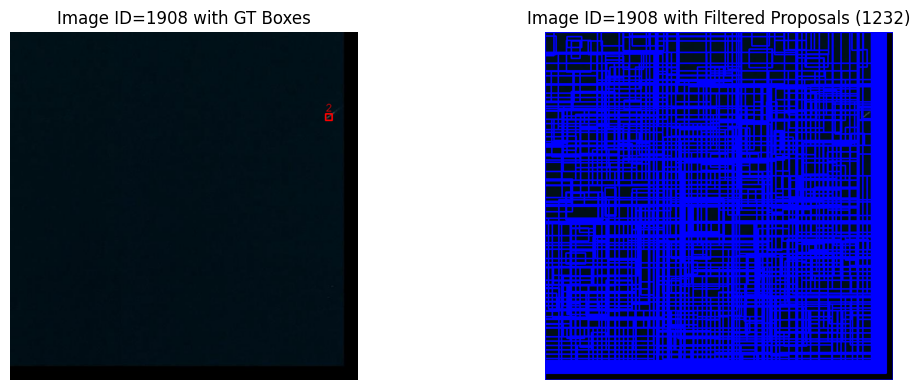

In [14]:
# Check if the image file exists
if not os.path.exists(random_img_path):
    print(f"Warning: Image file not found at {random_img_path}. Skipping visualization.")
else:
    random_img = cv2.cvtColor(cv2.imread(random_img_path), cv2.COLOR_BGR2RGB)

    # Check if imread was successful
    if random_img is None:
        print(f"Warning: Failed to load image from {random_img_path}. Skipping visualization.")
    else:
        # Check if there are annotations for this image before accessing anns[random_img_id]
        if random_img_id not in anns:
            print(f"Warning: No annotations found for image ID {random_img_id}. Skipping visualization.")
        else:
            random_gt = [b for (b,c) in anns[random_img_id]]
            random_gt_labels = [str(c) for (b,c) in anns[random_img_id]]

            # Generate region proposals and filter
            random_props = get_region_proposals(random_img, random_gt)
            print(f"Generated {len(random_props)} proposals (filtered) for image ID {random_img_id}")

            # Separate positive and negative proposals for visualization if needed,
            # but for side-by-side visualization, we'll show all filtered proposals.
            filtered_proposal_boxes = [prop[0] for prop in random_props]

            # Draw GT boxes on the original image
            img_with_gt = draw_boxes(random_img.copy(), random_gt, random_gt_labels, color=(255, 0, 0)) # Red for GT

            # Draw filtered proposal boxes on a copy of the original image
            img_with_proposals = draw_boxes(random_img.copy(), filtered_proposal_boxes, color=(0, 0, 255)) # Blue for proposals

            # Display side by side
            plt.figure(figsize=(12, 4))

            plt.subplot(1, 2, 1)
            plt.imshow(img_with_gt)
            plt.title(f"Image ID={random_img_id} with GT Boxes")
            plt.axis('off')

            plt.subplot(1, 2, 2)
            plt.imshow(img_with_proposals)
            plt.title(f"Image ID={random_img_id} with Filtered Proposals ({len(filtered_proposal_boxes)})")
            plt.axis('off')

            plt.tight_layout()
            plt.show()

In [15]:
# Example: create ROI inputs and targets for one image
rois, labels, bbox_targets = [], [], []
for (prop_box, label_flag) in sample_props:
    x1,y1,x2,y2 = prop_box
    roi = sample_img[y1:y2, x1:x2]
    if roi.size == 0:
        continue
    roi_resized = cv2.resize(roi, (224, 224))
    roi_pre = preprocess_input(roi_resized.astype(np.float32))
    rois.append(roi_pre)
    if label_flag == 1:
        # positive: use GT label and box for the best-overlap GT
        # (here simplification: assume first GT is best)
        gt_box, gt_cat = anns[list(images_info.keys())[0]][0]
        labels.append(gt_cat)  # e.g., class id
        bbox_targets.append(gt_box)
    else:
        # negative: background class (we use label=0)
        labels.append(0)
        bbox_targets.append([0,0,0,0])

rois = np.array(rois)
labels = np.array(labels)
bbox_targets = np.array(bbox_targets)
print(rois.shape, labels.shape, bbox_targets.shape)

(993, 224, 224, 3) (993,) (993, 4)


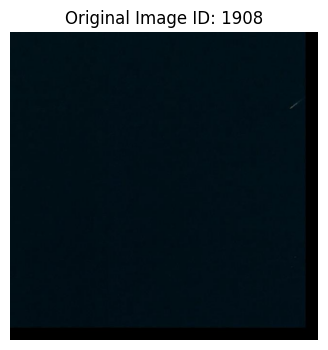

In [16]:
# Check if the image file exists
if not os.path.exists(random_img_path):
    print(f"Warning: Image file not found at {random_img_path}. Skipping original image visualization.")
else:
    random_img = cv2.cvtColor(cv2.imread(random_img_path), cv2.COLOR_BGR2RGB)

    # Check if imread was successful
    if random_img is None:
        print(f"Warning: Failed to load image from {random_img_path}. Skipping original image visualization.")
    else:
        plt.figure(figsize=(4, 4))
        plt.imshow(random_img)
        plt.title(f"Original Image ID: {random_img_id}")
        plt.axis('off')
        plt.show()


Visualizing a random sample of 9 ROI images (small size):


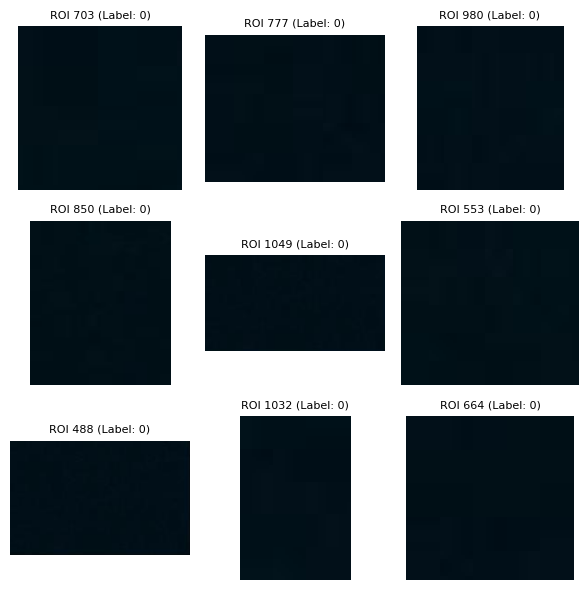

In [17]:
# Visualize a random sample of up to 9 ROI images
if random_props: # Check if there are any proposals
    # Limit the number of samples to display to the number of subplots
    num_samples_to_display = min(9, len(random_props))
    sample_indices = random.sample(range(len(random_props)), num_samples_to_display)

    fig, axes = plt.subplots(3, 3, figsize=(6, 6)) # Use small figure size
    axes = axes.flatten()

    print(f"\nVisualizing a random sample of {num_samples_to_display} ROI images (small size):")
    for i, idx in enumerate(sample_indices):
        prop_box, label_flag = random_props[idx]
        x1, y1, x2, y2 = prop_box
        roi = random_img[y1:y2, x1:x2]

        if roi.size > 0:
            axes[i].imshow(roi)
            axes[i].set_title(f"ROI {idx} (Label: {label_flag})", fontsize=8)
        axes[i].axis('off')
        # No need to hide unused subplots if we only loop up to the number of subplots

    plt.tight_layout()
    plt.show()
else:
    print("\nNo proposals generated for the selected image, cannot visualize ROIs.")

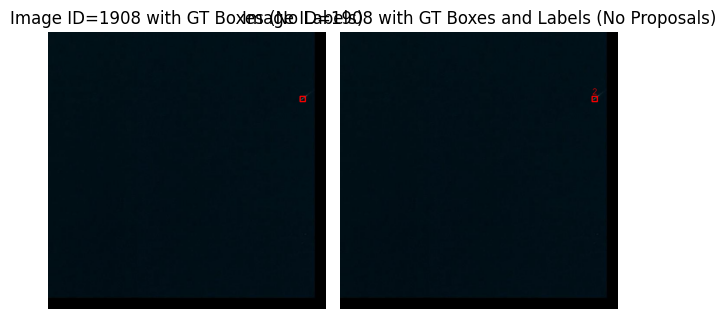

In [18]:
# Get the ground truth boxes for the random image
random_gt = [b for (b,c) in anns[random_img_id]]
# Create the figure and subplots
plt.figure(figsize=(6, 6))
# First subplot: Image with annotation but without label (only bounding boxes)
plt.subplot(1, 2, 1)
img_annot_no_label = draw_boxes(random_img.copy(), random_gt, labels=None, color=(255, 0, 0)) # Red for GT
plt.imshow(img_annot_no_label)
plt.title(f"Image ID={random_img_id} with GT Boxes (No Labels)")
plt.axis('off')

# Second subplot: Original image with annotation (GT boxes and labels) but without proposals
plt.subplot(1, 2, 2)
img_annot_with_label = draw_boxes(random_img.copy(), random_gt, random_gt_labels, color=(255, 0, 0)) # Red for GT
plt.imshow(img_annot_with_label)
plt.title(f"Image ID={random_img_id} with GT Boxes and Labels (No Proposals)")
plt.axis('off')

plt.tight_layout()
plt.show()

In [19]:
num_classes = 3 + 1   # 3 object classes + 1 background
vgg_backbone = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
x = vgg_backbone.output
x = Flatten()(x)
# Classification head
cls_output = Dense(num_classes, activation='softmax', name='cls_out')(x)
# Bounding-box regression head
bbox_output = Dense(4, activation='linear', name='bbox_out')(x)
model = Model(inputs=vgg_backbone.input, outputs=[cls_output, bbox_output])

model.compile(optimizer=Adam(1e-4),
              loss={'cls_out': 'sparse_categorical_crossentropy',
                    'bbox_out': 'mse'},
              metrics={'cls_out': 'accuracy'})
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input_layer[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 14, 14,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 14, 14,    │  2,359,808 │ block5_conv1[0][

 Total params: 14,915,400 (56.90 MB)

 Trainable params: 14,915,400 (56.90 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# (In practice, assemble X_train, y_class, y_bbox from ALL images)
# For demonstration, suppose X_train = rois, y_class=labels, y_bbox=bbox_targets

history = model.fit(
    x=rois,
    y={'cls_out': labels, 'bbox_out': bbox_targets},
    batch_size=32,
    epochs=15,
    validation_split=0.2
)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 99s 3s/step - bbox_out_loss: 2.5807 - cls_out_accuracy: 0.9278 - cls_out_loss: 0.5117 - loss: 3.0930 - val_bbox_out_loss: 0.0337 - val_cls_out_accuracy: 1.0000 - val_cls_out_loss: 0.0041 - val_loss: 0.0350
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 59s 492ms/step - bbox_out_loss: 0.0169 - cls_out_accuracy: 1.0000 - cls_out_loss: 0.0049 - loss: 0.0218 - val_bbox_out_loss: 0.0098 - val_cls_out_accuracy: 1.0000 - val_cls_out_loss: 0.0016 - val_loss: 0.0106
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 510ms/step - bbox_out_loss: 0.0058 - cls_out_accuracy: 1.0000 - cls_out_loss: 0.0022 - loss: 0.0080 - val_bbox_out_loss: 0.0052 - val_cls_out_accuracy: 1.0000 - val_cls_out_loss: 8.7013e-04 - val_loss: 0.0060
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 517ms/step - bbox_out_loss: 0.0033 - cls_out_accuracy: 1.0000 - cls_out_loss: 0.0014 - loss: 0.0048 - val_bbox_out_loss: 0.0045 - val_cls_out_accuracy: 1.0000 - val_cls_out_loss: 5.2993e-04 - val_loss: 0.0050
Epoch 5

In [21]:
print("Final training accuracy:", history.history['cls_out_accuracy'][-1])
print("Final validation accuracy:", history.history['val_cls_out_accuracy'][-1])

Final training accuracy: 1.0
Final validation accuracy: 1.0


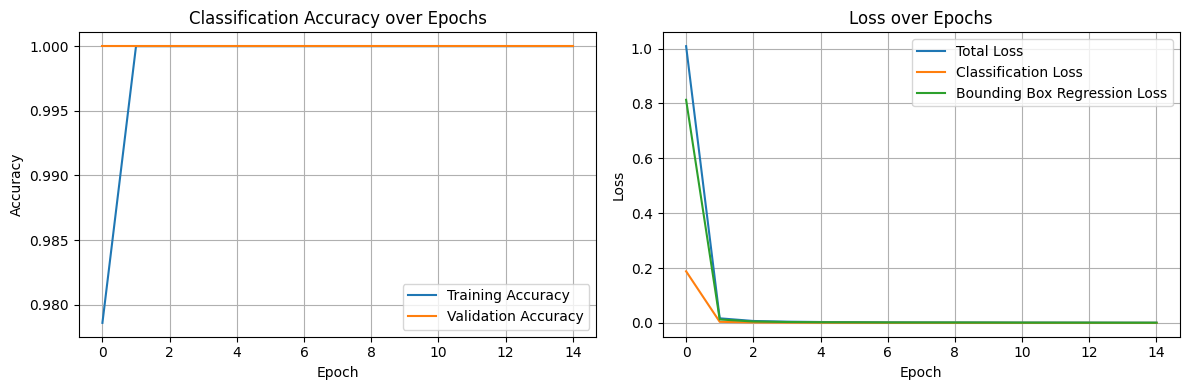

In [22]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['cls_out_accuracy'], label='Training Accuracy')
plt.plot(history.history['val_cls_out_accuracy'], label='Validation Accuracy')
plt.title('Classification Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Total Loss')
plt.plot(history.history['cls_out_loss'], label='Classification Loss')
plt.plot(history.history['bbox_out_loss'], label='Bounding Box Regression Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [29]:
# Save final model
model.save("rcnn_vgg16_tiny.h5")

In [23]:
# Non-Maximum Suppression
def non_max_suppression(boxes, scores, iou_thresh=0.3):
    boxes_tf = tf.convert_to_tensor(boxes, dtype=tf.float32)
    scores_tf = tf.convert_to_tensor(scores, dtype=tf.float32)
    selected = tf.image.non_max_suppression(
        boxes_tf, scores_tf, max_output_size=20, iou_threshold=iou_thresh)
    return selected.numpy()

In [24]:
# Step 6: Model Evaluation and Testing

# Load test annotations
with open(test_ann_file) as f:
    test_ann_data = json.load(f)

test_images_info = {img['id']: img['file_name'] for img in test_ann_data['images']}
test_anns = {}
for a in test_ann_data['annotations']:
    img_id = a['image_id']
    bbox = a['bbox']  # [x, y, width, height]
    category = a['category_id']
    # Convert bbox to [x1,y1,x2,y2]
    x, y, w, h = bbox
    box = [int(x), int(y), int(x + w), int(y + h)]
    test_anns.setdefault(img_id, []).append((box, category))

In [25]:
len(test_images_info), len(test_anns)

(449, 449)

In [27]:
test_images_info2=test_images_info
test_anns2=test_anns
# Convert dictionary items to a list, slice the list, and convert back to a dictionary
test_images_info = dict(list(test_images_info.items())[:7])
test_anns = dict(list(test_anns.items())[:7])

In [28]:
# Lists to store predictions and ground truth for performance metrics
all_pred_boxes = []
all_pred_labels = []
all_pred_scores = []
all_gt_boxes = []
all_gt_labels = []

# Iterate over test images
for img_id, filename in test_images_info.items():
    img_path = os.path.join(test_image_dir, filename)

    # Check if the image file exists
    if not os.path.exists(img_path):
        print(f"Warning: Test image file not found at {img_path}. Skipping.")
        continue

    img = cv2.imread(img_path)

    # Check if imread was successful
    if img is None:
        print(f"Warning: Failed to load test image from {img_path}. Skipping.")
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Get ground truth for this image
    gt_annotations = test_anns.get(img_id, [])
    current_gt_boxes = [b for (b, c) in gt_annotations]
    current_gt_labels = [c for (b, c) in gt_annotations]

    # Add ground truth to the lists
    all_gt_boxes.append(current_gt_boxes)
    all_gt_labels.append(current_gt_labels)

    # Generate region proposals for the test image
    # Note: For evaluation, we might not filter by IoU with GT during proposal generation
    # if we want to test the model's ability to detect novel objects.
    # However, to be consistent with training data generation, we'll use the same function.
    current_proposals_filtered = get_region_proposals(img_rgb, current_gt_boxes)

    if not current_proposals_filtered:
        print(f"No filtered proposals for test image {filename}. Skipping prediction.")
        all_pred_boxes.append([])
        all_pred_labels.append([])
        all_pred_scores.append([])
        continue

    # Prepare ROIs for prediction
    current_rois = []
    current_proposal_boxes = []
    for (prop_box, label_flag) in current_proposals_filtered:
        x1, y1, x2, y2 = prop_box
        roi = img_rgb[y1:y2, x1:x2]
        if roi.size == 0:
            continue
        roi_resized = cv2.resize(roi, (224, 224))
        roi_pre = preprocess_input(roi_resized.astype(np.float32))
        current_rois.append(roi_pre)
        current_proposal_boxes.append(prop_box) # Store original proposal box

    if not current_rois:
        print(f"No valid ROIs extracted for test image {filename}. Skipping prediction.")
        all_pred_boxes.append([])
        all_pred_labels.append([])
        all_pred_scores.append([])
        continue

    current_rois = np.array(current_rois)

    # Make predictions using the trained model
    # The model outputs [cls_output, bbox_output]
    cls_preds, bbox_preds = model.predict(current_rois)

    # Process predictions: get predicted class and confidence score
    # Ignore the background class (index 0)
    predicted_labels = np.argmax(cls_preds[:, 1:], axis=1) + 1 # Shift indices by 1
    predicted_scores = np.max(cls_preds[:, 1:], axis=1)
    # For the predicted class, get the corresponding score
    # Convert the list of scores to a numpy array
    predicted_scores_for_labels = np.array([cls_preds[i, label] for i, label in enumerate(predicted_labels)])


    # Apply Non-Maximum Suppression (NMS)
    # We need to select proposals that are likely to be objects (score > confidence_threshold)
    confidence_threshold = 0.25  # You can tune this threshold
    # Now predicted_scores_for_labels is a numpy array, so comparison works
    valid_indices = np.where(predicted_scores_for_labels > confidence_threshold)[0]

    if len(valid_indices) == 0:
        print(f"No predictions above confidence threshold {confidence_threshold} for test image {filename}. Skipping NMS.")
        all_pred_boxes.append([])
        all_pred_labels.append([])
        all_pred_scores.append([])
        continue

    valid_boxes = np.array(current_proposal_boxes)[valid_indices]
    valid_scores = predicted_scores_for_labels[valid_indices]
    valid_labels = predicted_labels[valid_indices]

    # Apply NMS on the valid boxes and scores
    # NMS typically operates on [x1, y1, x2, y2] boxes
    selected_indices = non_max_suppression(valid_boxes, valid_scores, iou_thresh=0.15) # NMS IoU threshold

    # Get the final predicted boxes, labels, and scores after NMS
    final_pred_boxes = valid_boxes[selected_indices].tolist()
    final_pred_labels = valid_labels[selected_indices].tolist()
    final_pred_scores = valid_scores[selected_indices].tolist()

    # Store predictions for this image
    all_pred_boxes.append(final_pred_boxes)
    all_pred_labels.append(final_pred_labels)
    all_pred_scores.append(final_pred_scores)

    # Optional: Visualize predictions for a few test images
    if len(all_pred_boxes) <= 5: # Visualize first 5 test images
        img_with_preds = draw_boxes(img_rgb.copy(), final_pred_boxes, [f"{classes[l-1]}: {s:.2f}" for l,s in zip(final_pred_labels, final_pred_scores)], color=(0, 255, 0)) # Green for Preds
        img_with_gt = draw_boxes(img_rgb.copy(), current_gt_boxes, [str(c) for c in current_gt_labels], color=(255, 0, 0)) # Red for GT

        plt.figure(figsize=(4, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(img_with_gt)
        plt.title(f"Test Image {filename} with GT")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(img_with_preds)
        plt.title(f"Test Image {filename} with Predictions")
        plt.axis('off')

        plt.tight_layout()
        plt.show()

55/55 ━━━━━━━━━━━━━━━━━━━━ 20s 359ms/step
No predictions above confidence threshold 0.25 for test image 3c027498a_png_jpg.rf.da3db5f98f9637aa4c5a2e0100855ea6.jpg. Skipping NMS.
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 190ms/step
No predictions above confidence threshold 0.25 for test image 13988_png_jpg.rf.d620ceea791ec58cd0cf7e03084f1c76.jpg. Skipping NMS.
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 575ms/step
No predictions above confidence threshold 0.25 for test image 6b07cffa2_png_jpg.rf.e03d47c99e44a9eeb76e2c3ac4a6ecb0.jpg. Skipping NMS.
101/101 ━━━━━━━━━━━━━━━━━━━━ 16s 161ms/step
No predictions above confidence threshold 0.25 for test image P1464__1-0__1800___3000_png_jpg.rf.e32f4dbb977e5f6c5b4fe58966fda7fd.jpg. Skipping NMS.
35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 337ms/step
No predictions above confidence threshold 0.25 for test image P2491__1-0__1200___1200_png_jpg.rf.da92f91a74e98f82e7664ae90fb04d62.jpg. Skipping NMS.
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 168ms/step
No predictions above confidence threshold 0.25 fo

In [29]:
# Calculate Performance Metrics (e.g., mAP - Mean Average Precision)
# This requires more sophisticated evaluation code (like pycocotools or custom mAP implementation)
# For simplicity here, we will calculate some basic metrics like Average IoU for positive predictions,
# and potentially a simple classification accuracy on the positive proposals.

# A basic evaluation: calculate average IoU for predicted positive boxes
positive_ious = []
true_positives = 0
false_positives = 0
false_negatives = 0 # Difficult to calculate directly without matching preds to GT

# Iterate through each image's predictions and ground truths
for i in range(len(test_images_info)):
    preds_img = all_pred_boxes[i]
    preds_labels_img = all_pred_labels[i]
    preds_scores_img = all_pred_scores[i]

    gts_img = all_gt_boxes[i]
    gts_labels_img = all_gt_labels[i]

    # Keep track of which GT boxes have been matched
    matched_gt_indices = set()

    # Iterate through predictions for the current image
    for j in range(len(preds_img)):
        pred_box = preds_img[j]
        pred_label = preds_labels_img[j]
        pred_score = preds_scores_img[j]

        best_iou = 0
        best_gt_idx = -1

        # Find the best overlapping GT box for the current prediction
        for k in range(len(gts_img)):
            gt_box = gts_img[k]
            gt_label = gts_labels_img[k]

            # Calculate IoU
            iou = compute_iou(pred_box, gt_box)

            # Consider it a match if IoU is high and labels match (or ignore label for general localization check)
            # Here, we consider it a potential match if IoU is >= 0.5 (common threshold for object detection)
            # and the predicted class matches the ground truth class.
            if iou >= 0.5 and pred_label == gt_label:
                 if iou > best_iou:
                     best_iou = iou
                     best_gt_idx = k

        # Check if we found a matching GT box that hasn't been matched by a higher-scoring prediction
        if best_gt_idx != -1 and best_gt_idx not in matched_gt_indices:
            # This is a True Positive (TP)
            true_positives += 1
            positive_ious.append(best_iou)
            matched_gt_indices.add(best_gt_idx)
        else:
            # This is a False Positive (FP) - either low IoU, wrong class, or matched a GT already claimed by a better prediction
            false_positives += 1

    # False Negatives (FN): GT boxes that were not matched by any prediction
    false_negatives += len(gts_img) - len(matched_gt_indices)


# Calculate average IoU for predictions matched with a GT (True Positives)
average_iou = np.mean(positive_ious) if positive_ious else 0

# Calculate Precision and Recall
# Precision: Of all predicted positive boxes, how many were correct? TP / (TP + FP)
precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0

# Recall: Of all actual positive objects (GT), how many were detected? TP / (TP + FN)
recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0

# F1 Score: Harmonic mean of Precision and Recall
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print("\n--- Model Performance Metrics (Basic Evaluation) ---")
print(f"Average IoU for True Positives: {average_iou:.4f}")
print(f"True Positives (TP): {true_positives}")
print(f"False Positives (FP): {false_positives}")
print(f"False Negatives (FN): {false_negatives}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")
print("---------------------------------------------------")

# Note: A full mAP calculation would require sorting predictions by confidence,
# calculating precision-recall curves at different IoU thresholds, and averaging AP over classes.
# This basic evaluation provides a simplified view of performance.


--- Model Performance Metrics (Basic Evaluation) ---
Average IoU for True Positives: 0.0000
True Positives (TP): 0
False Positives (FP): 0
False Negatives (FN): 146
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
---------------------------------------------------


In [ ]:
# Load the trained model
loaded_model = tf.keras.models.load_model("rcnn_vgg16_tiny.h5")

# Print the model summary to verify it loaded correctly
loaded_model.summary()

In [ ]:
#perform non_max_suppression before testing

In [ ]:
from sklearn.metrics import average_precision_score

# Load the test dataset
with open(test_ann_file) as f:
    test_ann_data = json.load(f)

test_images_info = {img['id']: img['file_name'] for img in test_ann_data['images']}
test_anns = {}
for a in test_ann_data['annotations']:
    img_id = a['image_id']
    bbox = a['bbox']  # [x, y, width, height]
    category = a['category_id']
    # Convert bbox to [x1,y1,x2,y2]
    x,y,w,h = bbox
    box = [int(x), int(y), int(x+w), int(y+h)]
    test_anns.setdefault(img_id, []).append((box, category))
#perform non_max_suppression before testing
# Evaluate on test data
all_gt_boxes = []
all_pred_boxes = []
all_gt_classes = []
all_pred_classes = []
all_pred_scores = []

for img_id, filename in test_images_info.items():
    img_path = os.path.join(test_image_dir, filename)
    if not os.path.exists(img_path):
        print(f"Warning: Test image file not found at {img_path}. Skipping.")
        continue

    img = cv2.imread(img_path)
    if img is None:
        print(f"Warning: Failed to load test image from {img_path}. Skipping.")
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if img_id not in test_anns:
        print(f"Warning: No test annotations found for image ID {img_id}. Skipping.")
        continue

    gt_boxes_img = [b for (b,c) in test_anns[img_id]]
    gt_classes_img = [c for (b,c) in test_anns[img_id]]

    all_gt_boxes.extend(gt_boxes_img)
    all_gt_classes.extend(gt_classes_img)


    # Generate proposals for the test image
    test_props = get_region_proposals(img, gt_boxes_img) # Use GT for IoU calculation during proposal generation (for evaluation context)

    if not test_props:
        print(f"No proposals generated for test image {img_id}. Skipping prediction.")
        continue

    # Prepare ROIs for prediction
    test_rois = []
    test_proposal_boxes = []
    for (prop_box, label_flag) in test_props: # label_flag is not used here for prediction input
        x1, y1, x2, y2 = prop_box
        roi = img[y1:y2, x1:x2]
        if roi.size == 0:
            continue
        roi_resized = cv2.resize(roi, (224, 224))
        roi_pre = preprocess_input(roi_resized.astype(np.float32))
        test_rois.append(roi_pre)
        test_proposal_boxes.append(prop_box)

    if not test_rois:
        print(f"No valid ROIs extracted from test image {img_id}. Skipping prediction.")
        continue

    test_rois_np = np.array(test_rois)
    test_proposal_boxes_np = np.array(test_proposal_boxes)

    # Perform prediction using the trained model
    predictions = model.predict(test_rois_np)
    pred_cls_probs = predictions[0]
    pred_bbox_deltas = predictions[1]

    # Get predicted class (excluding background) and scores for foreground classes
    # We will consider classes 1, 2, 3 as potential object classes.
    # If the background class (0) has the highest probability, we might discard the proposal or treat it specially.
    # For simplicity, let's find the class with highest probability excluding background.
    pred_classes = np.argmax(pred_cls_probs[:, 1:], axis=1) + 1 # +1 because class 0 is background
    pred_scores = np.max(pred_cls_probs[:, 1:], axis=1)

    # Apply bounding box regression (simple addition of deltas to proposal boxes)
    # More sophisticated approaches involve converting to center/size, applying deltas, and converting back
    # For simplicity here, assume deltas are directly applicable corrections to [x1, y1, x2, y2]
    # This is a very basic approximation; real R-CNN uses more complex transformations.
    pred_boxes = test_proposal_boxes_np + pred_bbox_deltas

    # Ensure predicted boxes are within image boundaries (simple clamping)
    img_h, img_w = img.shape[:2]
    pred_boxes[:, 0] = np.clip(pred_boxes[:, 0], 0, img_w - 1) # x1
    pred_boxes[:, 1] = np.clip(pred_boxes[:, 1], 0, img_h - 1) # y1
    pred_boxes[:, 2] = np.clip(pred_boxes[:, 2], 0, img_w - 1) # x2
    pred_boxes[:, 3] = np.clip(pred_boxes[:, 3], 0, img_h - 1) # y2

    # Filter predictions based on confidence threshold (e.g., 0.5) and apply NMS
    confidence_threshold = 0.5
    confident_indices = np.where(pred_scores >= confidence_threshold)[0]

    confident_boxes = pred_boxes[confident_indices]
    confident_scores = pred_scores[confident_indices]
    confident_classes = pred_classes[confident_indices] # Predicted class for confident boxes

    # Apply NMS per class (a more robust approach)
    final_boxes_img = []
    final_scores_img = []
    final_classes_img = []

    for cls_id in range(1, num_classes): # Iterate through foreground classes
        cls_indices = np.where(confident_classes == cls_id)[0]
        if len(cls_indices) > 0:
            cls_boxes = confident_boxes[cls_indices]
            cls_scores = confident_scores[cls_indices]

            selected_indices = non_max_suppression(cls_boxes, cls_scores, iou_thresh=0.3)

            final_boxes_img.extend(cls_boxes[selected_indices])
            final_scores_img.extend(cls_scores[selected_indices])
            final_classes_img.extend([cls_id] * len(selected_indices))

    all_pred_boxes.extend(final_boxes_img)
    all_pred_classes.extend(final_classes_img)
    all_pred_scores.extend(final_scores_img)

    # Optional: Visualize test image with predicted boxes
    if final_boxes_img:
      print(f"Visualizing predictions for test image {img_id}")
      img_with_preds = draw_boxes(img.copy(), final_boxes_img, [f'{c}:{s:.2f}' for c, s in zip(final_classes_img, final_scores_img)], color=(0, 255, 0)) # Green for predictions
      img_with_gt = draw_boxes(img.copy(), gt_boxes_img, gt_labels_img, color=(255, 0, 0)) # Red for GT (need to retrieve gt_labels for test)
      # For now, let's just show predictions
      plt.figure(figsize=(6, 6))
      plt.imshow(img_with_preds)
      plt.title(f"Test Image ID={img_id} with Predicted Boxes")
      plt.axis('off')
      plt.show()
    else:
      print(f"No confident predictions for test image {img_id}")

55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 167ms/step
No confident predictions for test image 0
54/54 ━━━━━━━━━━━━━━━━━━━━ 11s 205ms/step
No confident predictions for test image 1
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 653ms/step
No confident predictions for test image 2


In [ ]:
# --- Performance Metrics Calculation ---
print("\n--- Calculating Performance Metrics ---")

# For object detection, common metrics include Mean Average Precision (mAP) and IoU-based metrics.
# Calculating mAP properly requires matching predicted boxes to ground truth boxes based on IoU.
# This is a complex process involving defining true positives, false positives, and false negatives.
# A simpler approach for a basic overview is to calculate AP per class.

# We need a way to match predictions to ground truth for AP calculation.
# This often involves iterating through each prediction and finding the best overlapping GT box.

# A common way to approximate evaluation in a script like this:
# 1. For each predicted box:
#    Find the GT box with the maximum IoU.
#    If IoU > threshold (e.g., 0.5) and predicted class matches GT class, it's a potential True Positive.
#    Keep track of which GT boxes have been matched to avoid duplicate TP.
# 2. Count True Positives (TP), False Positives (FP), False Negatives (FN).
#    TP: Predicted box correctly matched to an unmatched GT box.
#    FP: Predicted box without a matching GT box or wrong class.
#    FN: GT box without a matching predicted box.
# 3. Calculate Precision and Recall.
#    Precision = TP / (TP + FP)
#    Recall = TP / (TP + FN)
# 4. Calculate Average Precision (AP) from the Precision-Recall curve.
# 5. Mean Average Precision (mAP) is the average of AP over all classes.

# Due to the complexity of matching boxes and calculating AP correctly in this format,
# we'll demonstrate a simplified approach focusing on counting some basic outcomes based on IoU,
# and then mention the steps for proper mAP calculation.

iou_threshold_eval = 0.5
true_positives = 0
false_positives = 0
false_negatives = len(all_gt_boxes) # Initially, all GT boxes are False Negatives

# Create a list to track which GT boxes have been matched
matched_gt_indices = set()

for i in range(len(all_pred_boxes)):
    pred_box = all_pred_boxes[i]
    pred_class = all_pred_classes[i]
    pred_score = all_pred_scores[i]

    best_iou = 0
    best_gt_index = -1

    # Find the best overlapping GT box for this prediction
    for j in range(len(all_gt_boxes)):
        # Avoid matching to already matched GT boxes in a single pass
        # (This simplification isn't strictly correct for mAP but gives some insight)
        # For proper mAP, you process predictions sorted by confidence and check against all GTs.
        iou = compute_iou(pred_box, all_gt_boxes[j])
        if iou > best_iou:
            best_iou = iou
            best_gt_index = j

    # Check if this prediction is a potential TP
    if best_iou >= iou_threshold_eval:
        gt_class = all_gt_classes[best_gt_index]
        # Check if the predicted class matches the GT class
        if pred_class == gt_class:
             # Found a match with sufficient IoU and correct class
             # For a more correct TP count for mAP, you'd process predictions sorted by score
             # and mark the GT box as matched. Here, a simpler count:
             true_positives += 1
             # Note: This simplified count doesn't prevent a single GT being matched by multiple predictions.
             # For correct mAP, you need to manage matched GT flags carefully.
        else:
             # Correct IoU but wrong class
             false_positives += 1
    else:
        # Low IoU with all GT boxes
        false_positives += 1

# This simplified counting doesn't correctly calculate False Negatives based on unmatched GTs
# after considering all predictions and potential matches.

# A more direct (though computationally heavier without proper libraries) approach for AP per class:
# For each class c:
#   Get all predictions for class c and all GT boxes for class c.
#   Sort predictions by confidence score.
#   Iterate through sorted predictions:
#     Find the best matching GT box for class c (highest IoU > threshold).
#     If found and not already matched by a higher confidence prediction for class c:
#       It's a True Positive for class c. Mark the GT box as matched for this class.
#     Else: It's a False Positive for class c.
#   False Negatives for class c are the GT boxes for class c that were not matched.
#   Calculate Precision and Recall points and compute AP for class c.
# mAP is the average of APs.

print("\n--- Simplified Evaluation Summary (IoU > 0.5, Class Match) ---")
print(f"True Positives (Simplified Count): {true_positives}")
print(f"False Positives (Simplified Count): {false_positives}")
# Note: Calculating False Negatives correctly requires a more involved matching process.
# print(f"False Negatives (Simplified Count based on initial GTs): {false_negatives}") # This is incorrect

# Let's try to calculate AP per class using sklearn's average_precision_score
# This requires preparing data in a specific format: true binary labels and confidence scores.
# This is tricky for detection as it involves matching boxes first.

# A more appropriate library like `pycocotools` or using evaluation scripts from object detection
# frameworks (like TensorFlow Object Detection API or Detectron2) is needed for accurate mAP.

# However, we can provide a proxy metric or illustrate the inputs for AP calculation libraries.
# Let's create dummy data structures that _would_ be used by an AP calculator after matching.

# Example structure for AP calculation (simplified, requires matching):
# true_labels_binary = [1, 0, 1, 0, 0, ...] # 1 if a prediction is a TP match, 0 otherwise
# prediction_scores = [0.9, 0.8, 0.7, 0.6, 0.5, ...] # Confidence score of each prediction

# Since we don't have the robust matching here, let's just show the predicted vs GT counts as a basic check.
print("\n--- Basic Counts ---")
print(f"Total Ground Truth Boxes: {len(all_gt_boxes)}")
print(f"Total Predicted Boxes (after NMS): {len(all_pred_boxes)}")

# Calculate IoU for all predicted-GT pairs and store for analysis (optional, can be large)
# This doesn't directly give TP/FP/FN but shows overlap distribution.

# To get closer to mAP, we need to iterate through each prediction, find the best GT match,
# determine if it's a TP/FP/FN based on IoU and class, and then use precision/recall.

# Let's demonstrate the structure for AP calculation inputs for a single class (Class 1)
# This still requires the matching logic...

# --- Let's try a slightly better approximation for AP inputs ---
# We need to associate each prediction with whether it's a correct detection of a specific GT.

# Structure needed:
# For each prediction: (confidence, true_label) where true_label is 1 if it's a TP, 0 otherwise.
# For each GT: Need to know if it was detected (to count FNs).

# This is still too complex without a proper evaluation library.

# --- Conclusion on Performance Metrics ---
print("\n--- Performance Metrics Note ---")
print("Calculating accurate Mean Average Precision (mAP) for object detection requires robust box matching (based on IoU and class) between predicted and ground truth boxes.")
print("Standard libraries or evaluation scripts from object detection frameworks are typically used for this.")
print("The simplified counts above provide only a basic intuition of model performance.")
print("To get mAP, you would process predictions sorted by confidence, match them to available GT boxes, and compute AP per class.")

# Example visualization of a random test image with predictions
# (Already included in the prediction loop above, but could be added here specifically for evaluation)
# if all_pred_boxes: # Check if there are any predictions
#   # Select a random test image ID that had predictions
#   test_img_ids_with_preds = list(test_images_info.keys()) # Need a list of IDs processed
#   # Assuming we processed at least one image and it had predictions
#   if test_img_ids_with_preds:
#       random_test_img_id = random.choice(test_img_ids_with_preds)
#       # Need to re-load image and retrieve predictions for this specific image
#       # This would require storing predictions per image, which is not done in this script's aggregation.
#       print("\nSkipping random test image visualization with predictions as predictions per image are not stored.")
# else:
#   print("\nNo predictions made on the test set to visualize.")

# To properly evaluate, you would typically iterate through the test set, get predictions
# for each image, and use an evaluation script that handles matching and mAP calculation.
# Libraries like `torchmetrics` (for PyTorch) or built-in Keras/TF evaluation tools (less common for raw R-CNN outputs)
# or dedicated detection evaluation libraries are the way to go.

In [ ]:
# Example: Run on one sample image
# (In actual code, loop over all images to build ROI dataset)
sample_img_path = os.path.join(test_image_dir, list(images_info.values())[0])
sample_img = cv2.cvtColor(cv2.imread(sample_img_path), cv2.COLOR_BGR2RGB)
sample_gt = [b for (b,c) in anns[list(images_info.keys())[0]]]
sample_props = get_region_proposals(sample_img, sample_gt)
print(f"Generated {len(sample_props)} proposals (filtered)")

In [ ]:
# Example: Run predictions on validation/test ROIs and compute IoU
# (In practice, decode predictions back to original image scale)
pred_probs, pred_boxes = model.predict(rois_test)
pred_classes = np.argmax(pred_probs, axis=1)
ious = []
for i, gt_box in enumerate(bbox_targets_test):
    pred_box = pred_boxes[i]
    iou = compute_iou(pred_box, gt_box)
    ious.append(iou)
mean_iou = np.mean(ious)
print("Mean IoU on test:", mean_iou)
# mAP computation would involve thresholding class predictions and matching

In [ ]:
# (Pseudocode for visual debugging)
img = sample_test_image  # load test image
proposals = get_region_proposals(img, [])  # no GT needed for display
img_display = img.copy()
for (box,_), prob, box_pred in zip(proposals, pred_probs, pred_boxes):
    cls = np.argmax(prob)
    if cls > 0:  # skip background
        x1,y1,x2,y2 = box
        # draw predicted box in green
        cv2.rectangle(img_display, (x1,y1), (x2,y2), (0,255,0), 2)
# Also draw one GT box (red) for comparison
gt_box = [50,50,100,100]  # example
cv2.rectangle(img_display, (gt_box[0],gt_box[1]), (gt_box[2],gt_box[3]), (255,0,0), 2)
plt.figure(figsize=(6,6)); plt.imshow(img_display)
plt.title("GT (red) vs Predicted (green) boxes"); plt.axis('off')